In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data3,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_3D,net_3D_fix,S_valgrad,error_general_3D,main_fix,draw
CUDA_LAUNCH_BLOCKING=2

def f_y(x, x_min,x_max,y_min,y_max,z_min,z_max,center,r):
    r_y = np.linalg.norm(x - center, axis=-1) 
    
    # Apply the piecewise function
    f_y_values = np.where(r_y < r, r - r_y, 0.0)
    return f_y_values

def ana_S(x,x_min,x_max,y_min,y_max,z_min,z_max,a,b,r): #x为数据，a，b均为中心点
    return f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,a,r)-f_y(x,x_min,x_max,y_min,y_max,z_min,z_max,b,r)

    

cuda:2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
S_num_5=np.load("./noise=5%/S_num_0.0009999999999999998.npy")
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
z = np.linspace(0, 1, 301)
X, Y, Z = np.meshgrid(x, y,z,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel(),Z.ravel())).T
center=np.array([[0.3,0.5,0.3],[0.5,0.5,0.8]])
r=0.2


In [3]:
YY,ZZ=np.meshgrid(y, z,indexing='ij')
XX,ZZ=np.meshgrid(x, z,indexing='ij')

In [4]:
reload(draw)

<module 'draw' from '/mnt/store/hxw-y23/code/Ex4.7/./main_code/draw.py'>

Plot saved as ./noise=5%/visual/S_true_x1_mid.pdf


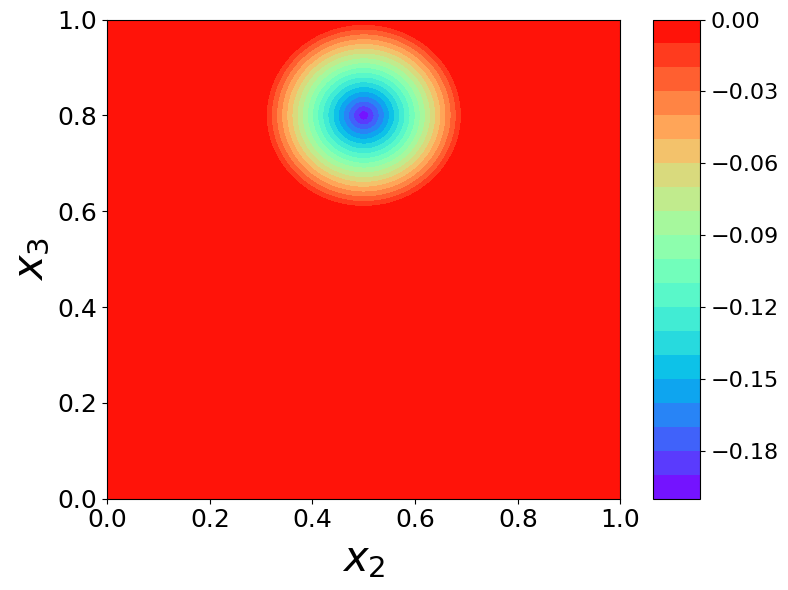

Plot saved as ./noise=5%/visual/S_num_x1_mid.pdf


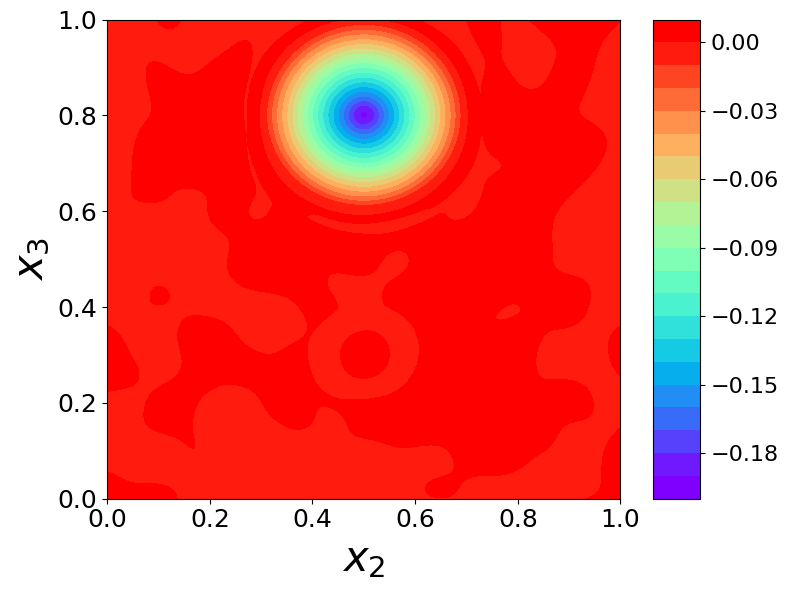

Plot saved as ./noise=5%/visual/S_true_x2_mid.pdf


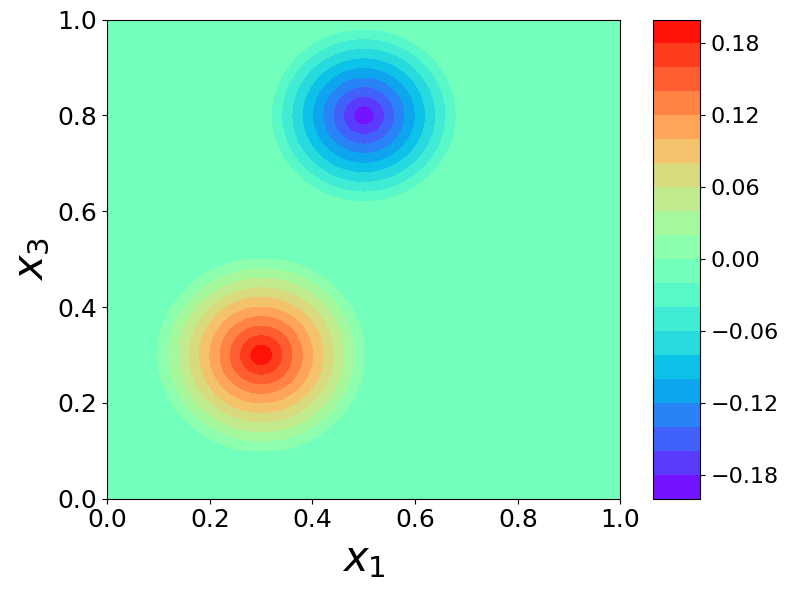

Plot saved as ./noise=5%/visual/S_num_x2_mid.pdf


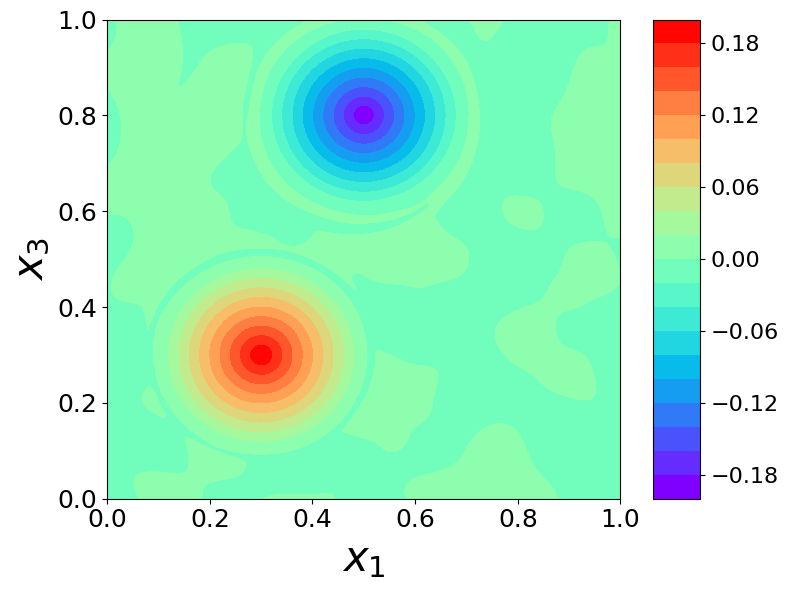

In [5]:
S_true=ana_S(samples,[],[],[],[],[],[],center[0],center[1],r).reshape(len(x),len(y),len(z))
ratio1=center[0]
ratio2=center[1]
S_num_x1_mid=S_num_5[int(0.5*S_num_5.shape[0])+1-1,:,:].reshape(len(y),len(z))
S_true_x1_mid=S_true[int(ratio1[1]*S_true.shape[1])+1-1,:,:].reshape(len(y),len(z))
S_num_x2_mid=S_num_5[:,int(0.5*S_num_5.shape[2])+1-1,:].reshape(len(y),len(z))
S_true_x2_mid=S_true[:,int(0.5*S_true.shape[2])+1-1,:].reshape(len(y),len(z))

output_dictionary="./noise=5%/visual/"
draw.draw(YY,ZZ,S_true_x1_mid,[],"$x_2$","$x_3$",[],output_dictionary,"S_true_x1_mid.pdf","")
draw.draw(YY,ZZ,S_num_x1_mid,[],"$x_2$","$x_3$",[],output_dictionary,"S_num_x1_mid.pdf","")
draw.draw(XX,ZZ,S_true_x2_mid,[],"$x_1$","$x_3$",[],output_dictionary,"S_true_x2_mid.pdf","")
draw.draw(XX,ZZ,S_num_x2_mid,[],"$x_1$","$x_3$",[],output_dictionary,"S_num_x2_mid.pdf","")

Plot saved as ./noise=5%/visual/abs_S_x1.pdf


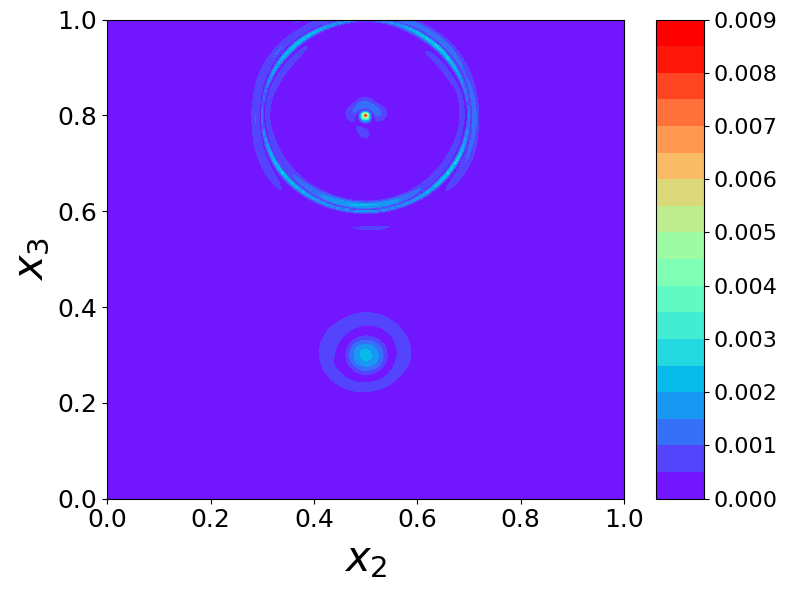

Plot saved as ./noise=5%/visual/abs_S_x2.pdf


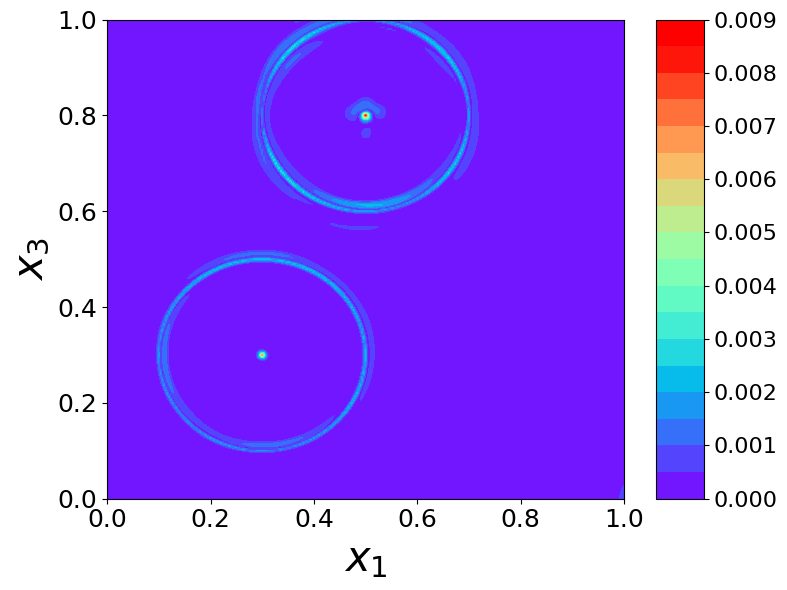

In [6]:
output_dictionary="./noise=5%/visual/"
draw.draw(YY,ZZ,np.abs(S_true_x1_mid-S_num_x1_mid),[],"$x_2$","$x_3$",[],output_dictionary,"abs_S_x1.pdf"," ")
draw.draw(YY,ZZ,np.abs(S_true_x2_mid-S_num_x2_mid),[],"$x_1$","$x_3$",[],output_dictionary,"abs_S_x2.pdf"," ")

In [7]:
S_num_store=np.load("./noise=5%/S_num_store.npy")
S_num_last=S_num_store[-1]

In [8]:
x_101 = np.linspace(0, 1, 101)
y_101 = np.linspace(0, 1, 101)
YY_101,ZZ_101=np.meshgrid(x_101, y_101,indexing='ij')

Plot saved as ./noise=5%/visual/S_num_x1_mid_ada
Plot saved as ./noise=5%/visual/S_num_1D_x2.pdf


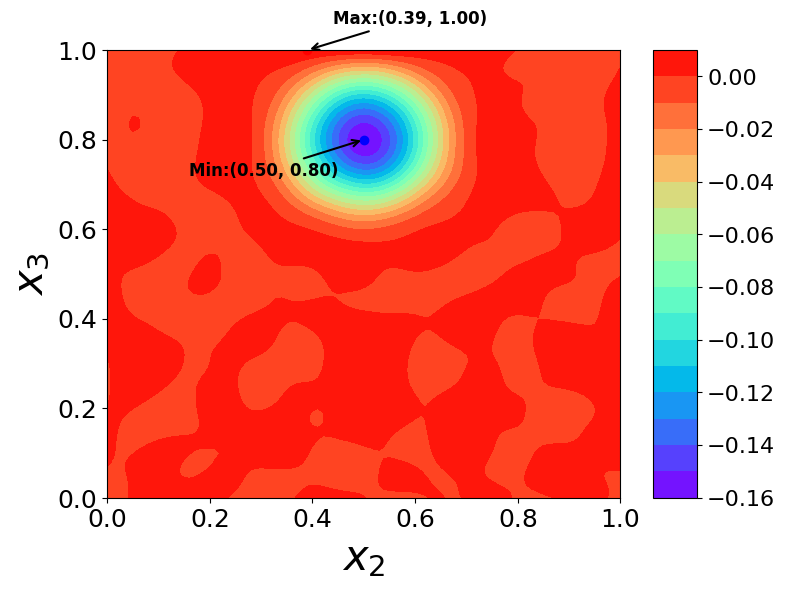

<Figure size 600x360 with 0 Axes>

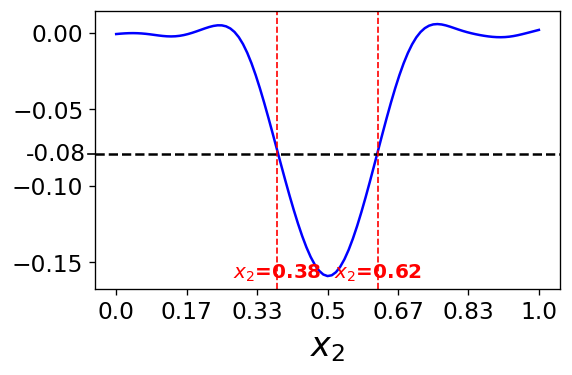

Plot saved as ./noise=5%/visual/S_num_x2_mid_ada
Plot saved as ./noise=5%/visual/S_num_1D_x1.pdf


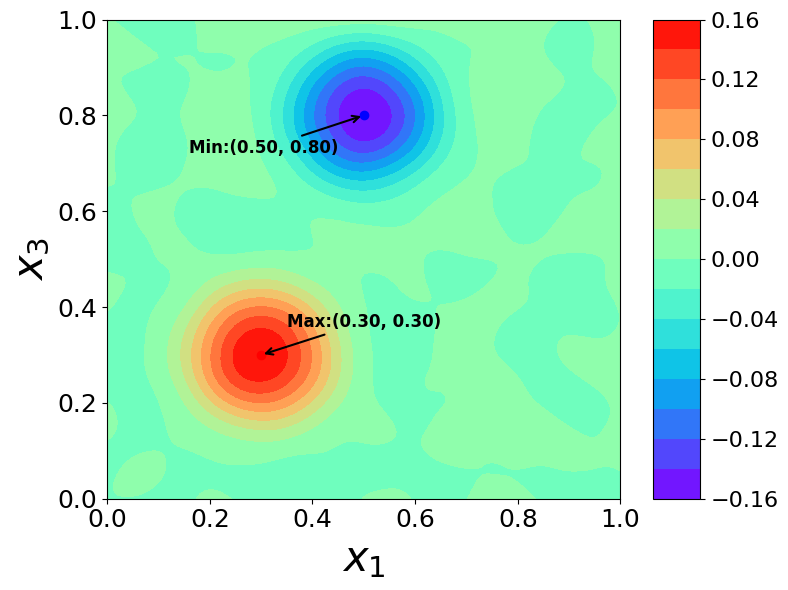

<Figure size 600x360 with 0 Axes>

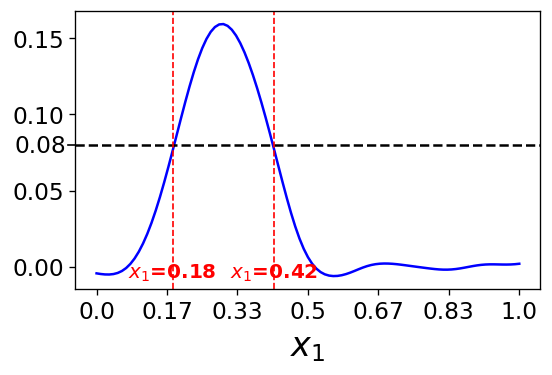

Plot saved as ./noise=5%/visual/S_num_x2_mid_ada
Plot saved as ./noise=5%/visual/S_num_1D_x3.pdf


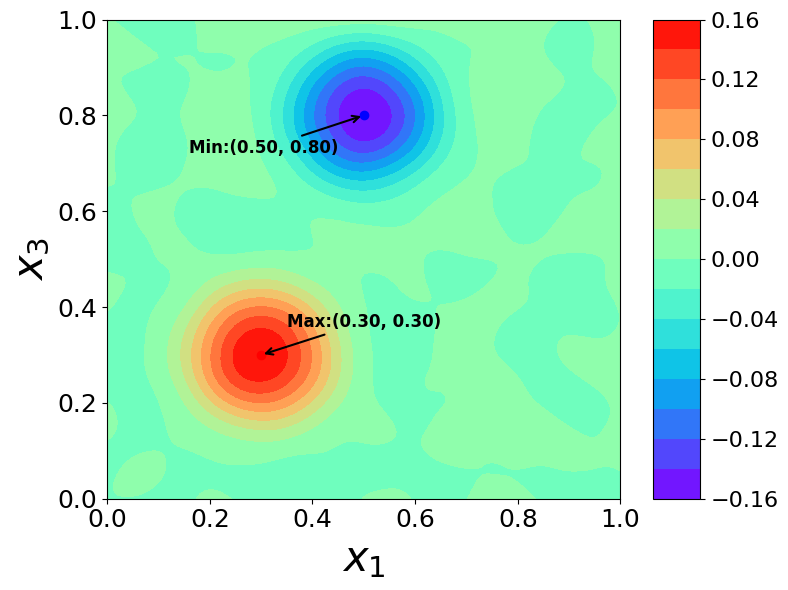

<Figure size 600x360 with 0 Axes>

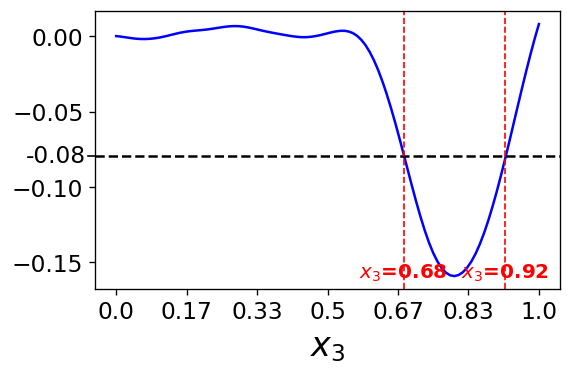

In [9]:
S_num_x1_mid_ada=S_num_last[int(0.5*S_num_last.shape[0])+1-1,:,:].reshape(101,101)
S_num_x2_mid_ada=S_num_last[:,int(0.5*S_num_last.shape[2])+1-1,:].reshape(101,101)
S_num_1D_x1=S_num_last[:,int(ratio1[1]*S_num_last.shape[1])+1-1,int(ratio1[2]*S_num_last.shape[2])+1-1]
S_num_1D_x2=S_num_last[int(ratio2[0]*S_num_last.shape[0])+1-1,:,int(ratio2[2]*S_num_last.shape[2])+1-1]
S_num_1D_x3=S_num_last[int(ratio2[0]*S_num_last.shape[0])+1-1,int(ratio2[1]*S_num_last.shape[1])+1-1,:]
draw.draw(YY_101,ZZ_101,S_num_x1_mid_ada,S_num_1D_x2,"$x_2$","$x_3$","$x_2$",output_dictionary,"S_num_x1_mid_ada","S_num_1D_x2.pdf",True,True)
draw.draw(YY_101,ZZ_101,S_num_x2_mid_ada,S_num_1D_x1,"$x_1$","$x_3$","$x_1$",output_dictionary,"S_num_x2_mid_ada","S_num_1D_x1.pdf",True,True)
draw.draw(YY_101,ZZ_101,S_num_x2_mid_ada,S_num_1D_x3,"$x_1$","$x_3$","$x_3$",output_dictionary,"S_num_x2_mid_ada","S_num_1D_x3.pdf",True,True)

In [10]:
g_S=np.load("./noise=5%/g_S.npy")
S_num_store=np.load("./noise=5%/S_num_store.npy")

/mnt/store/hxw-y23/code/Ex4.7/./main_code/bound_detect1.py:167: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(center_point[0], center_point[1], center_point[2], color='black', s=100, marker='x', edgecolors='black', label='Center Point', zorder=200)


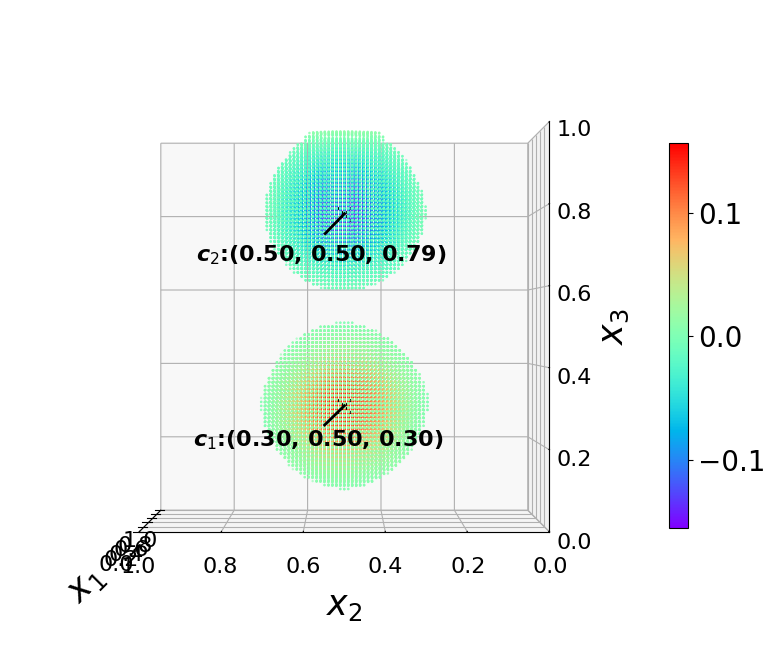

In [11]:
import bound_detect1
reload(bound_detect1)
center=np.array([[0.29984818, 0.49992798, 0.30034535],[0.49993043, 0.49965242, 0.7918808 ]])
mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point= bound_detect1.detect_3d(g_S, S_num_store[-1], [0,0,0], [1,1,1], 3, 100, 0,180,center,"S",
              output_directory="./noise=5%/visual/", output_filename="plot_3d_y.pdf")

/mnt/store/hxw-y23/code/Ex4.7/./main_code/bound_detect1.py:167: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(center_point[0], center_point[1], center_point[2], color='black', s=100, marker='x', edgecolors='black', label='Center Point', zorder=200)


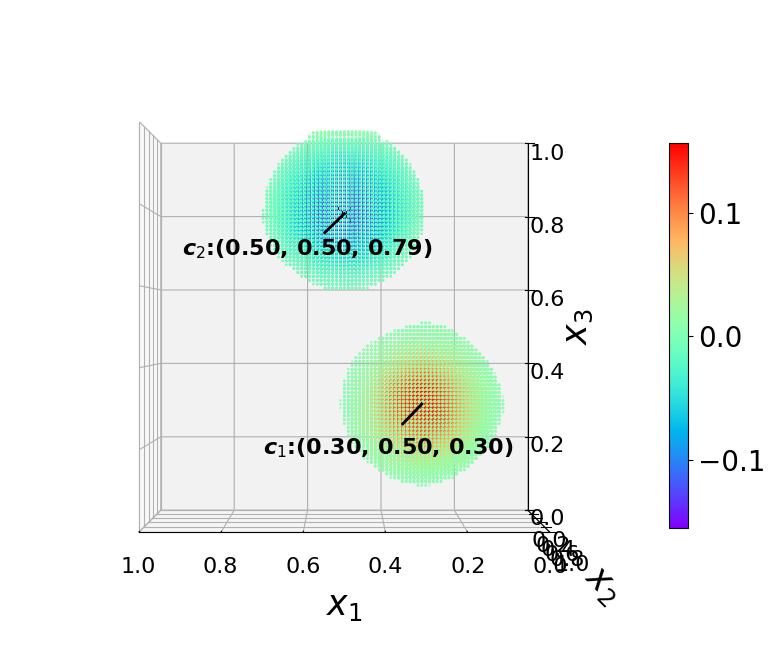

In [12]:
import bound_detect1
reload(bound_detect1)
center=np.array([[0.29984818, 0.49992798, 0.30034535],[0.49993043, 0.49965242, 0.7918808 ]])
mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point= bound_detect1.detect_3d(g_S, S_num_store[-1], [0,0,0], [1,1,1], 3, 100, 0,90,center,"S",
              output_directory="./noise=5%/visual/", output_filename="plot_3d_x.pdf")

/mnt/store/hxw-y23/code/Ex4.7/./main_code/bound_detect1.py:167: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(center_point[0], center_point[1], center_point[2], color='black', s=100, marker='x', edgecolors='black', label='Center Point', zorder=200)


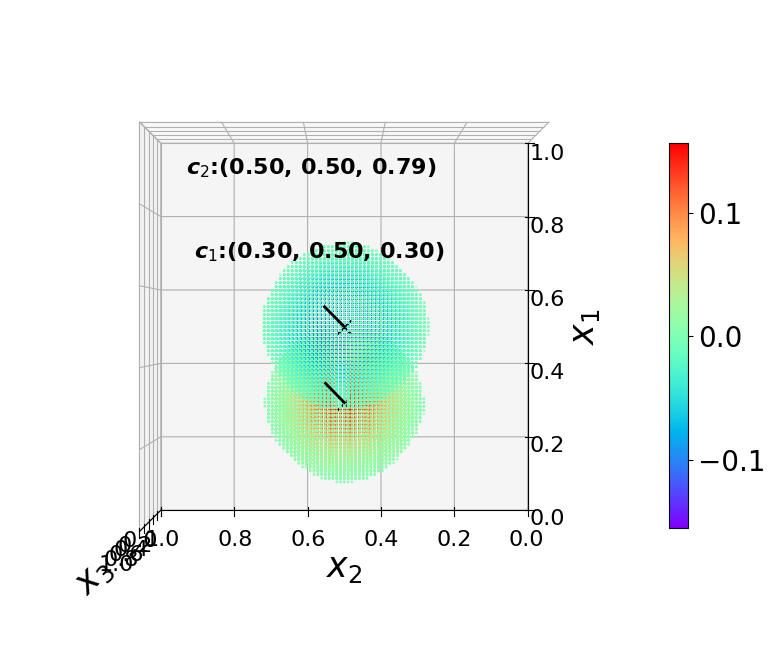

In [13]:
import bound_detect1
reload(bound_detect1)
center=np.array([[0.29984818, 0.49992798, 0.30034535],[0.49993043, 0.49965242, 0.7918808 ]])
mapped_mask_points,min_x_point,max_x_point,min_y_point,max_y_point,min_z_point,max_z_point= bound_detect1.detect_3d(g_S, S_num_store[-1], [0,0,0], [1,1,1], 3, 100, 90,180,center,"S",
              output_directory="./noise=5%/visual/", output_filename="plot_3d_z.pdf")

In [14]:
##加载cell_stores
import pickle
with open('./noise=5%/cells_store.pkl', 'rb') as f:
    cell_stores = pickle.load(f)

Plotting 1436 cells. Levels: 0 to 2


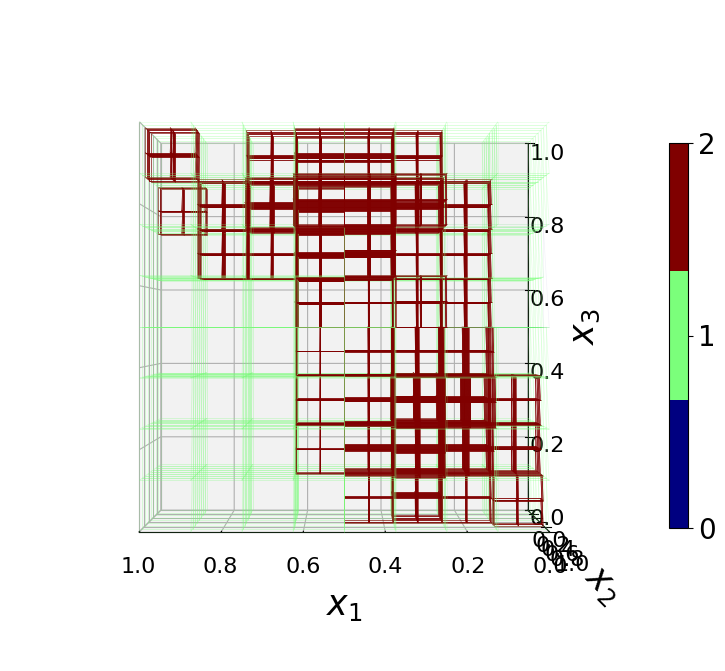

In [15]:
import Visual_cell
reload(Visual_cell)


views = [(0, 90)]
Visual_cell.visualize_3d_grid(cell_stores[-1], title="3D Adaptive Grid", views=views, alpha=0.9, output_directory="./noise=5%/visual/", output_filename="cell_x.pdf")

Plotting 1436 cells. Levels: 0 to 2


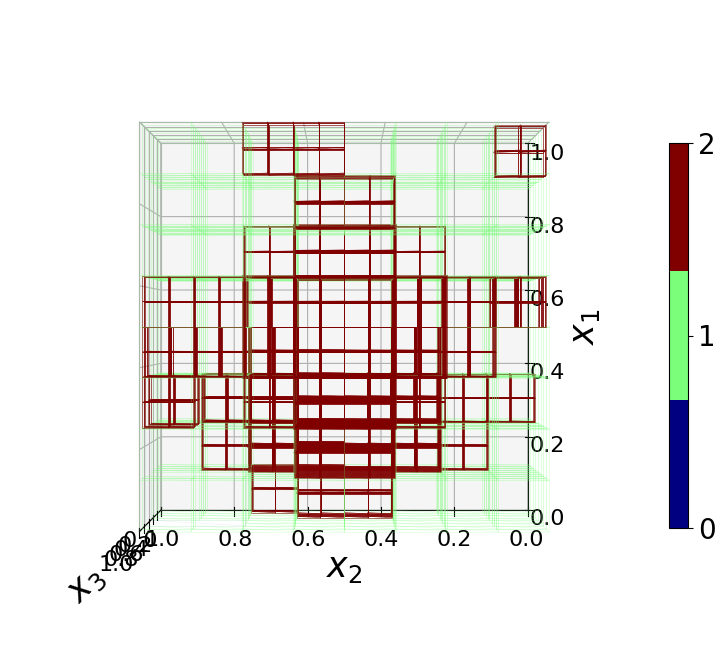

In [16]:
import Visual_cell
reload(Visual_cell)


views = [(90, 180)]
Visual_cell.visualize_3d_grid(cell_stores[-1], title="3D Adaptive Grid", views=views, alpha=0.9, output_directory="./noise=5%/visual/", output_filename="cell_z.pdf")

Plotting 1436 cells. Levels: 0 to 2


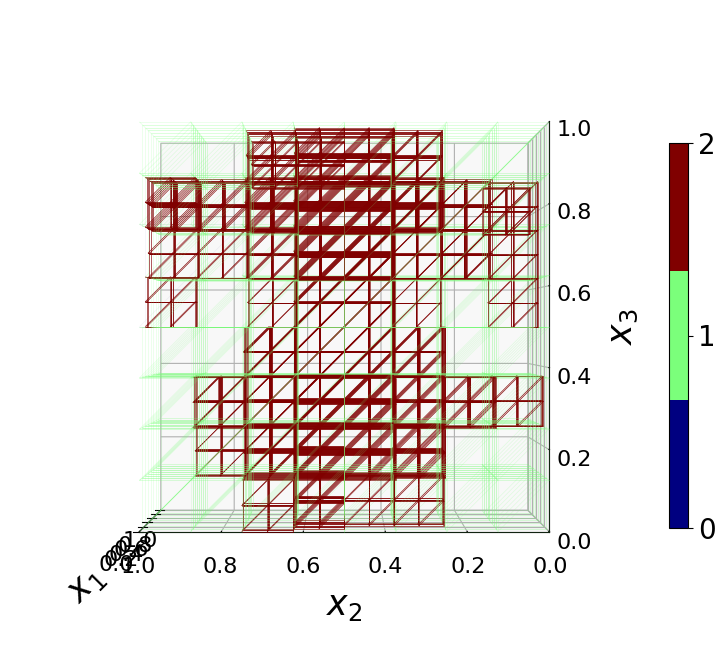

In [17]:
#import Visual_cell
reload(Visual_cell)


views = [(0, 180)]
Visual_cell.visualize_3d_grid(cell_stores[-1], title="3D Adaptive Grid", views=views, alpha=0.9, output_directory="./noise=5%/visual/", output_filename="cell_y.pdf")